In [1]:
#  import libraries
import h5py
import os, sys
import zipfile
import numpy as np
from mpi4py import MPI
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator, StrMethodFormatter

# --- Configuration ---
from ICESEE.config._utility_imports import *
from ICESEE.src.utils.tools import get_grid_dimensions, midprofiles_coords, midpoint_rect, midindices, load_hu_obs_from_h5

[ICESEE] Running in Jupyter - disabling command line arguments


In [2]:
# Path to the ZIP file
# check if .zip file exists
# if not os.path.exists("results.zip"):
#     print("The file 'results.zip' does not exist.")
#     sys.exit()
    
# zip_file_path = "results.zip"
# # zip_file_path = "results_loc_joint.zip"
# output_folder = "results"

# # Unzip the file
# if os.path.exists(zip_file_path):
#     with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
#         # Create the output folder if it doesn't exist
#         if not os.path.exists(output_folder):
#             os.makedirs(output_folder)
#         zip_ref.extractall(output_folder)
#     print(f"Extracted '{zip_file_path}' to '{output_folder}'")
# else:
#     print(f"The file '{zip_file_path}' does not exist.")


In [3]:
results_dir = "_modelrun_datasets"
figure_dir = os.path.join(results_dir, 'figures'); os.makedirs(figure_dir, exist_ok=True)
filter_type = "true-wrong"
# Summary metadata is stored beside the ensemble/state datasets.
file_path = f"{results_dir}/{filter_type}-icepack.h5"
datasets_tw = extract_datasets_from_h5(file_path)
t=datasets_tw['t']
# ensemble_true_state = datasets_tw['ensemble_true_state']
# ensemble_nurged_state = datasets_tw['ensemble_nurged_state']
# w = datasets_tw['w']
ind_m = datasets_tw['obs_index']
tm_m = datasets_tw['obs_max_time'][0]
run_mode = datasets_tw['run_mode'][0]

[ICESEE] Reading data from _modelrun_datasets/true-wrong-icepack.h5...
[ICESEE] Dataset 'Lxy' extracted with shape (2,)
[ICESEE] Dataset 'b_io' extracted with shape (2,)
[ICESEE] Dataset 'nxy' extracted with shape (2,)
[ICESEE] Dataset 'obs_index' extracted with shape (10,)
[ICESEE] Dataset 'obs_max_time' extracted with shape (1,)
[ICESEE] Dataset 'run_mode' extracted with shape (1,)
[ICESEE] Dataset 't' extracted with shape (241,)
[ICESEE] Data extraction complete.


In [4]:
filter_type = "EnKF"
if run_mode != 0:
    file_path = f"{results_dir}/{filter_type}-icepack.h5"
    datasets = extract_datasets_from_h5(file_path)
    ensemble_vec_full = datasets["ensemble_vec_full"]
    ensemble_vec_mean = datasets["ensemble_vec_mean"] 
    ensemble_bg       = datasets["ensemble_bg"]
else:
    file_path = '_modelrun_datasets/icesee_ensemble_data.h5'
    import h5py
    with h5py.File(file_path, 'r') as f:
        ensemble_vec_full = f['ensemble'][:]
        ensemble_vec_mean = f['ensemble_mean'][:]
        # ensemble_true_state = f['true_state'][:]
        # ensemble_nurged_state = f['nurged_state'][:]
        ensemble_bg = None

In [5]:
with h5py.File('_modelrun_datasets/true_nurged_states.h5', 'r') as f:
    ensemble_true_state = f['true_state'][:]
    ensemble_nurged_state = f['nurged_state'][:]

with h5py.File('_modelrun_datasets/synthetic_obs.h5','r') as f:
    # Transparently supports both dense ('hu_obs') and mode-2's default
    # compact ('hu_obs_compact' + 'obs_indices') observation storage.
    w = load_hu_obs_from_h5(f)
     # print(f["true_state"])

Midpoint indices ix = 24, iy = 16
At h_indx = 392 profile 
(10,) (10,)


Text(0.5, 1.0, 'middle profile at h_indx = 392')

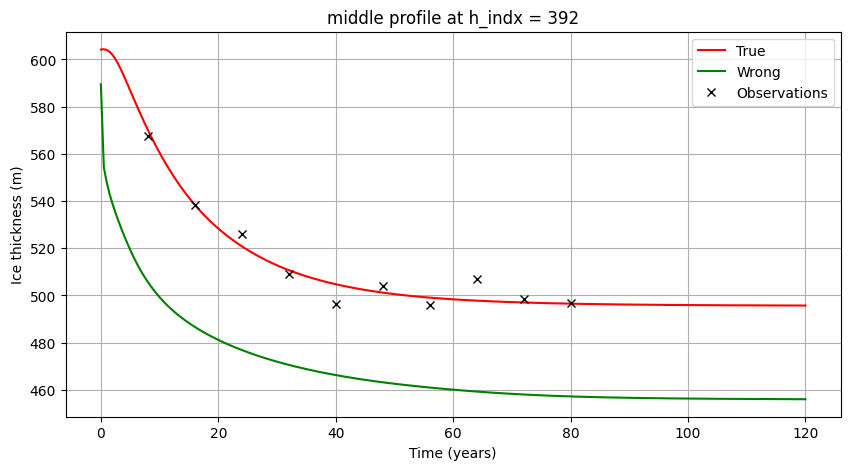

In [6]:
nt = ensemble_true_state.shape[1]; num_steps = nt-1
ndim = ensemble_true_state.shape[0]
hdim = ndim//4 # [h,u,v,smb]

Lx, Ly = datasets_tw["Lxy"][0], datasets_tw["Lxy"][1]
nx, ny = datasets_tw["nxy"][0], datasets_tw["nxy"][1]
mx,my = get_grid_dimensions(nx,ny,hdim)
# lets get the middle index
# vert_prof, horiz_prof = midprofiles_coords(mx,my,hdim)
# print(f"Vertical profile at x = {vert_prof}, Horizontal profile at y = {horiz_prof}")
ix,iy= midindices(mx,my)
print(f"Midpoint indices ix = {ix}, iy = {iy}")

# plot the ensemble_true_state and ensemble_nurged_state
htrue = ensemble_true_state[:hdim,:]
hnurge = ensemble_nurged_state[:hdim,:]

# define profile flag
profile_flag = "middle" # begining, middle, end, random

if profile_flag == "begining":
    h_indx = 0 # first profile
elif profile_flag == "middle":
    # h_indx = ix*iy # middle profile
    # h_indx = ix*iy + iy//2
    # h_indx = (ix*(my-1)) + (my-1)//2
    # h_indx = ix*(my-1) + 0
    h_indx = ((ix//2)*(my-1)) + (iy)//2  #(ix/2,iy/2) point 
elif profile_flag == "end":
    h_indx = (mx-1)*(my-1) + 0
    # h_indx = (mx-1)*(my-1) + (my-1)//2
# elif profile_flag == "random":
#     h_indx = np.random.randint(htrue.shape[0])

print(f"At h_indx = {h_indx} profile ")

h_true = htrue[h_indx,:]
h_nurged = hnurge[h_indx,:]

plt.figure(figsize=(10,5))
plt.plot(t,h_true,'r',label='True')
plt.plot(t,h_nurged,'g',label='Wrong')
obs = w[h_indx,:]; print(obs.shape,t[ind_m].shape)
plt.plot(t[ind_m],obs,'kx',label="Observations")
plt.xlabel('Time (years)')
plt.ylabel('Ice thickness (m)')
plt.legend()
plt.grid()
plt.title(f"{profile_flag} profile at h_indx = {h_indx}")

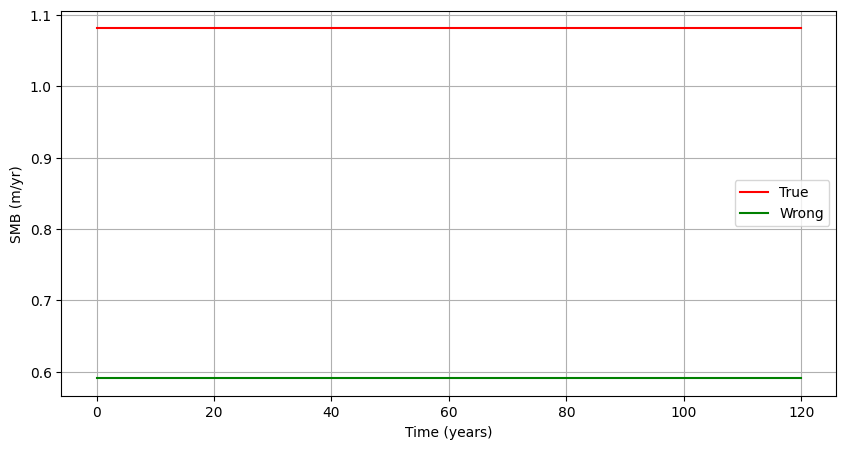

In [7]:
# extract smb
smbtrue = ensemble_true_state[3*hdim:,:]
smbnurged = ensemble_nurged_state[3*hdim:,:]

# plot the smbtrue
plt.figure(figsize=(10,5))
plt.plot(t,smbtrue[h_indx,:],'r',label='True')
plt.plot(t,smbnurged[h_indx,:],'g',label='Wrong')
plt.xlabel('Time (years)')
plt.ylabel('SMB (m/yr)')
plt.legend()
plt.grid()

In [8]:
from firedrake import *
import firedrake

Lx, Ly = datasets_tw["Lxy"][0], datasets_tw["Lxy"][1]
nx, ny = datasets_tw["nxy"][0], datasets_tw["nxy"][1]

mesh = firedrake.RectangleMesh(nx, ny, Lx, Ly,quadrilateral=True)
Q = firedrake.FunctionSpace(mesh, "CG", 2)
V = firedrake.VectorFunctionSpace(mesh, "CG", 2)
x, y = firedrake.SpatialCoordinate(mesh)
b_in, b_out = datasets_tw["b_io"][0], datasets_tw["b_io"][1]
b = firedrake.Function(Q).interpolate(b_in - (b_in - b_out) * x / Lx)

a_in = firedrake.Constant(1.7)
δa = firedrake.Constant(-2.7)
a = firedrake.Function(Q).interpolate(a_in + δa * x / Lx)

# form a rectangular mesh and get x, y coordinates
x, y = np.meshgrid(np.linspace(0, Lx, nx), np.linspace(0, Ly, ny))
print(nx, ny, Lx, Ly,b_in, b_out)

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


24 16 5000 1200 200.0 -400.0


In [9]:
# h_indx = ix * my + ((my-1) // 2)
# Assuming a nodal grid
row, col = h_indx // (my-1), h_indx % (mx-1)
dx, dy = Lx/(my-1), Ly/(mx-1)
x_h,y_h = col*dx, row*dy

dx,dy = Lx/(mx-1), Ly/(mx-1)
# x_h,y_h = (col+0.5)*dx, (row+0.5)*dy

print(f"At h_indx = {h_indx}, x = {x_h}, y = {y_h}")

At h_indx = 392, x = 1250.0, y = 300.0


In [10]:
# x_h,y_h = 1100,300

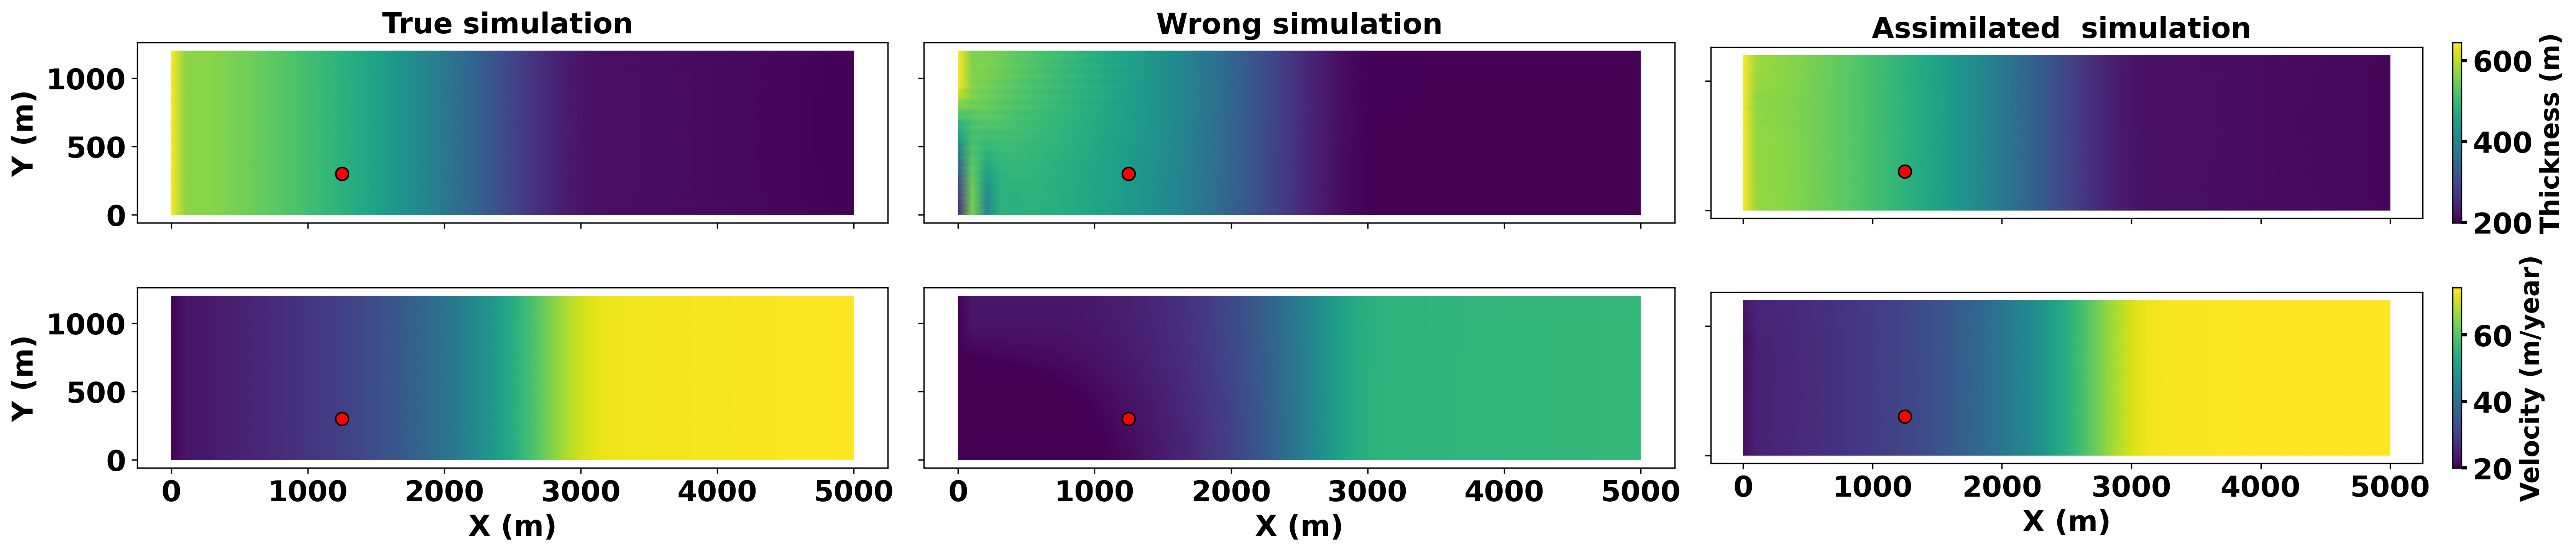

In [11]:
from firedrake import div
import copy
import icepack
import icepack.plot
import matplotlib.pyplot as plt
import numpy as np

# Create a 2x3 subplot grid for 3 simulations (True, Wrong, EnKF), with thickness and velocity
fig, axes = icepack.plot.subplots(2, 3, figsize=(22.5, 5.2), dpi=300)

step = nt-2
# step =0

u_indx = hdim + h_indx
v_indx = 2*hdim + h_indx

# Compute min/max for thickness and velocity to set consistent colorbar ranges
hhtrue = firedrake.Function(Q)
hhnurge = firedrake.Function(Q)
hhenkf = firedrake.Function(Q)
hhtrue.dat.data[:] = copy.deepcopy(ensemble_true_state[:hdim, step])
hhnurge.dat.data[:] = copy.deepcopy(ensemble_nurged_state[:hdim, step])
hhenkf.dat.data[:] = copy.deepcopy(ensemble_vec_mean[:hdim, step])
h_min = hhtrue.dat.data.min()
h_max = hhtrue.dat.data.max()

uutrue = firedrake.Function(V)
uunurge = firedrake.Function(V)
uuenkf = firedrake.Function(V)
uutrue.dat.data[:, 0] = copy.deepcopy(ensemble_true_state[hdim:2*hdim, step])
uutrue.dat.data[:, 1] = copy.deepcopy(ensemble_true_state[2*hdim:3*hdim, step])
uunurge.dat.data[:, 0] = copy.deepcopy(ensemble_nurged_state[hdim:2*hdim, step])
uunurge.dat.data[:, 1] = copy.deepcopy(ensemble_nurged_state[2*hdim:3*hdim, step])
uuenkf.dat.data[:, 0] = copy.deepcopy(ensemble_vec_mean[hdim:2*hdim, step])
uuenkf.dat.data[:, 1] = copy.deepcopy(ensemble_vec_mean[2*hdim:3*hdim, step])
# Compute magnitude of velocity for consistent scaling
u_true_mag = np.sqrt(uutrue.dat.data[:, 0]**2 + uutrue.dat.data[:, 1]**2)
u_nurge_mag = np.sqrt(uunurge.dat.data[:, 0]**2 + uunurge.dat.data[:, 1]**2)
u_enkf_mag = np.sqrt(uuenkf.dat.data[:, 0]**2 + uunurge.dat.data[:, 1]**2)
u_min = u_true_mag.min()
u_max = u_true_mag.max()

# True simulation - Thickness
colors = firedrake.tripcolor(hhtrue, axes=axes[0][0], vmin=h_min, vmax=h_max)
# fig.colorbar(colors, ax=axes[0][0], fraction=0.012, pad=0.04, label="Thickness (m)")
axes[0][0].set_title("True simulation ", fontsize=18, fontweight='bold')

# True simulation - Velocity
colors = firedrake.tripcolor(uutrue, axes=axes[1][0], vmin=u_min, vmax=u_max)
# fig.colorbar(colors, ax=axes[1][0], fraction=0.012, pad=0.04, label="Velocity (m/year)")

# Wrong simulation - Thickness
colors = firedrake.tripcolor(hhnurge, axes=axes[0][1], vmin=h_min, vmax=h_max)
# fig.colorbar(colors, ax=axes[0][1], fraction=0.012, pad=0.04, label="Thickness (m)")
axes[0][1].set_title("Wrong simulation", fontsize=18, fontweight='bold')


# Wrong simulation - Velocity
colors = firedrake.tripcolor(uunurge, axes=axes[1][1], vmin=u_min, vmax=u_max)
# fig.colorbar(colors, ax=axes[1][1], fraction=0.012, pad=0.04, label="Velocity (m/year)")

# EnKF simulation - Thickness
colors = firedrake.tripcolor(hhenkf, axes=axes[0][2],  vmin=h_min, vmax=h_max)
cbar = fig.colorbar(colors, ax=axes[0][2], fraction=0.012, pad=0.04, label="Thickness (m)")
cbar.set_label("Thickness (m)", fontsize=16, fontweight='bold')
cbar.ax.yaxis.set_tick_params(labelsize=12, width=2)
axes[0][2].set_title("Assimilated  simulation ", fontsize=18, fontweight='bold')
for label in cbar.ax.yaxis.get_ticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(18)


# EnKF simulation - Velocity
colors = firedrake.tripcolor(uuenkf, axes=axes[1][2], vmin=u_min, vmax=u_max)
cbar = fig.colorbar(colors, ax=axes[1][2], fraction=0.012, pad=0.04, label="Velocity (m/year)")
cbar.set_label("Velocity (m/year)", fontsize=16, fontweight='bold')
cbar.ax.yaxis.set_tick_params(labelsize=12, width=2)
for label in cbar.ax.yaxis.get_ticklabels():
    label.set_fontweight('bold')
    label.set_fontsize(18)

for ax in axes.flatten():
    # ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_xticklabels([int(tick) for tick in ax.get_xticks()], fontweight='bold', fontsize=18)
    # ax.set_yticklabels([int(tick) for tick in ax.get_yticks()], fontweight='bold', fontsize=18)
    # ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    # ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    # ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
     # size via tick_params
    ax.tick_params(axis='both', which='major', labelsize=18)

    # plt.setp(ax.get_xticklabels(), fontweight='bold')
    plt.setp(ax.get_yticklabels(), fontweight='bold')
    # ax.tick_params(labelsize=18)
    if ax in [axes[0][0], axes[1][0]]:
        # ax.set_xticks([])
        ax.set_ylabel("Y (m)", fontsize=18, fontweight='bold')
        # ax.set_yticklabels([int(tick) for tick in ax.get_yticks()], fontweight='bold', fontsize=14)
    if ax in [axes[1][0], axes[1][1], axes[1][2]]:
        ax.set_xlabel("X (m)", fontsize=18, fontweight='bold')
        # ax.set_xticklabels([int(tick) for tick in ax.get_xticks()], fontweight='bold', fontsize=14)

    # remove yticklabels for right plots and xticklabels for top plots
    if ax not in [axes[0][0], axes[1][0]]:
        ax.set_yticklabels([])
    
    if ax not in [axes[1][0], axes[1][1], axes[1][2]]:
        ax.set_xticklabels([])

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# x_h, y_h = mesh.coordinates.dat.data[h_indx]
# x_h= i x*(my-1)
# x_h = 424
# y_h = 200
# --- Plot marker or line for h_indx on all subplots ---
for irow in range(2):
    for icol in range(3):
        ax = axes[irow][icol]
        # Example 1: mark single point
        ax.plot(x_h, y_h, marker='o', markersize=8, color='red', markeredgecolor='black', zorder=10)
        # Example 2: optional crosshair lines for profile
        # ax.axvline(x_h, color='red', linestyle='--', linewidth=1.8)
        # ax.axhline(y_h, color='red', linestyle='--', linewidth=1.8)
        # ax.text(
        #     x_h + 100, y_h + 100,
        #     f"$h_{{idx}}$",
        #     color='red', fontsize=16, fontweight='bold'
        # )
        # ax.text(
        #     x_h + 100, y_h + 100,
        #     f"",
        #     color='red', fontsize=16, fontweight='bold'
        # )


plt.tight_layout()
plt.savefig(os.path.join(figure_dir, f"hu_snapshot_{profile_flag}_s.png"), bbox_inches='tight', dpi=300)

In [12]:
import string

def add_panel_labels(ax_array, fontsize=16):
    """
    Publication-style panel labels with bold text + white background box.
    Left column: (a1), (b1), ...
    Right column: (a2), (b2), ...
    """
    letters = list(string.ascii_lowercase)

    bbox_kw = dict(
        boxstyle="round,pad=0.18",
        facecolor="white",
        edgecolor="black",
        linewidth=1.2,
        alpha=0.95
    )

    for i in range(ax_array.shape[0]):
        # left column
        ax_array[i, 0].text(
            0.015, 0.92,
            rf"$\mathbf{{({letters[i]}_1)}}$",
            transform=ax_array[i, 0].transAxes,
            fontsize=fontsize,
            va="top", ha="left",
            bbox=bbox_kw,
            zorder=10
        )

        # right column
        ax_array[i, 1].text(
            0.015, 0.92,
            rf"$\mathbf{{({letters[i]}_2)}}$",
            transform=ax_array[i, 1].transAxes,
            fontsize=fontsize,
            va="top", ha="left",
            bbox=bbox_kw,
            zorder=10
        )

def style_axes(ax_array):
    for a in ax_array.ravel():
        # thicker spines
        for sp in a.spines.values():
            sp.set_linewidth(1.4)

        # ticks
        a.tick_params(axis="both", which="major", labelsize=12, width=1.3, length=6, direction="out")
        a.tick_params(axis="both", which="minor", width=1.0, length=3, direction="out")

        # optional: turn off grid (publishable)
        a.grid(False)

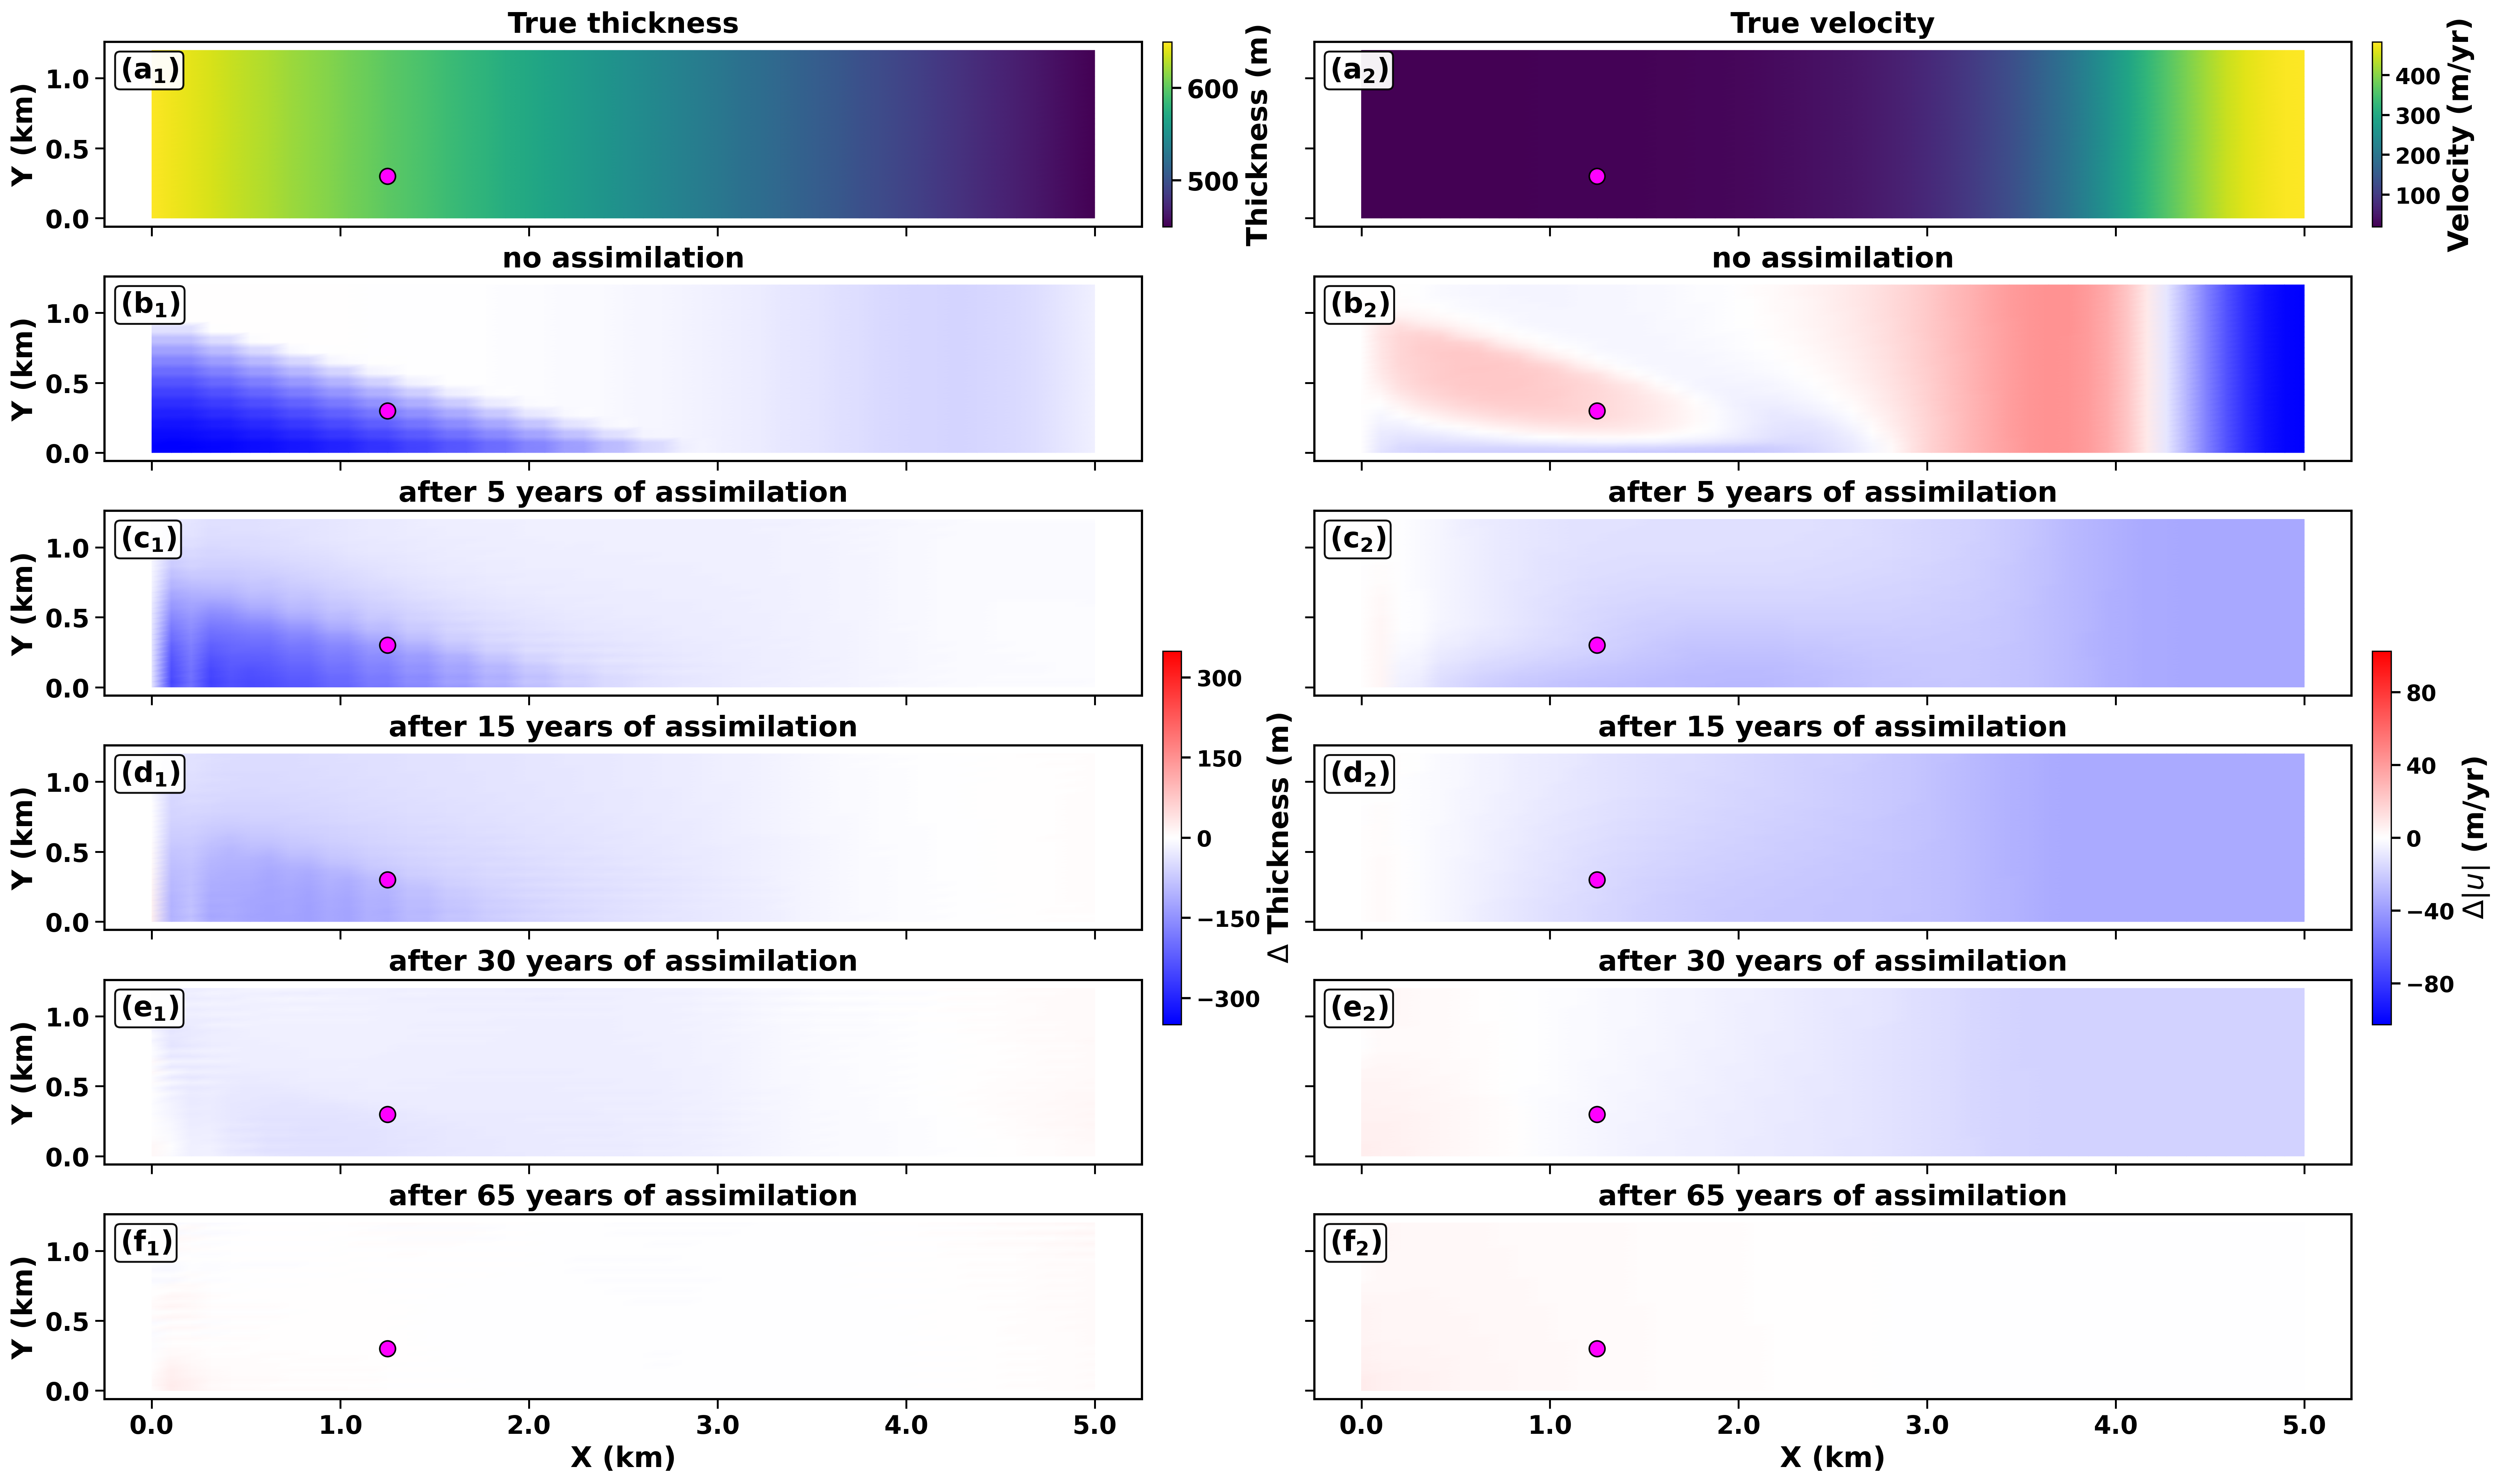

In [13]:
# ===============================================
# Firedrake functions (True / Wrong / Assimilated)
# ===============================================
def get_firedrake_functions(ensemble_true_state, ensemble_nurged_state, ensemble_vec_mean, hdim, step):
    hhtrue, hhnurge, hhenkf = firedrake.Function(Q), firedrake.Function(Q), firedrake.Function(Q)
    hhtrue.dat.data[:]  = ensemble_true_state[:hdim, step]
    hhnurge.dat.data[:] = ensemble_nurged_state[:hdim, step]     # "wrong" / no-assim
    hhenkf.dat.data[:]  = ensemble_vec_mean[:hdim, step]         # assimilated

    uutrue, uunurge, uuenkf = firedrake.Function(V), firedrake.Function(V), firedrake.Function(V)
    uutrue.dat.data[:, 0]  = ensemble_true_state[hdim:2*hdim, step]
    uutrue.dat.data[:, 1]  = ensemble_true_state[2*hdim:3*hdim, step]
    uunurge.dat.data[:, 0] = ensemble_nurged_state[hdim:2*hdim, step]
    uunurge.dat.data[:, 1] = ensemble_nurged_state[2*hdim:3*hdim, step]
    uuenkf.dat.data[:, 0]  = ensemble_vec_mean[hdim:2*hdim, step]
    uuenkf.dat.data[:, 1]  = ensemble_vec_mean[2*hdim:3*hdim, step]

    u_true_mag  = np.sqrt(uutrue.dat.data[:,0]**2  + uutrue.dat.data[:,1]**2)
    u_wrong_mag = np.sqrt(uunurge.dat.data[:,0]**2 + uunurge.dat.data[:,1]**2)
    u_enkf_mag  = np.sqrt(uuenkf.dat.data[:,0]**2  + uuenkf.dat.data[:,1]**2)

    # True ranges at this step
    hmin, hmax = hhtrue.dat.data.min(), hhtrue.dat.data.max()
    umin, umax = u_true_mag.min(), u_true_mag.max()

    return hhtrue, hhnurge, hhenkf, uutrue, uunurge, uuenkf, u_true_mag, u_wrong_mag, u_enkf_mag, hmin, hmax, umin, umax


# ===============================================
# Choose steps and build figure
# ===============================================
# steps = [5, 15, 25]
steps = [5, 15, 30, 65]
no_of_rows = len(steps) + 2

# fig = plt.figure(figsize=(40, 18), dpi=300)
# fig = plt.figure(figsize=(7.2, 6.0), dpi=300, constrained_layout=True)
fig = plt.figure(figsize=(22, 13), dpi=300, constrained_layout=True)
# gs = gridspec.GridSpec(no_of_rows, 2, figure=fig, hspace=0.20, wspace=0.08)
gs = gridspec.GridSpec(no_of_rows, 2, figure=fig, 
                       height_ratios=[1]*no_of_rows,
                       hspace=0.001, wspace=0.001)
ax = np.array([[fig.add_subplot(gs[i, j]) for j in range(2)] for i in range(no_of_rows)])


# ===============================================
# Precompute GLOBAL diff limits so all diff plots share ONE scale
# ===============================================
# Get truth/wrong/enkf at step 0 for "Wrong-True"
hhtrue_0, hhnurge_0, hhenkf_0, uutrue_0, uunurge_0, uuenkf_0, u_true_mag_0, u_wrong_mag_0, u_enkf_mag_0, hmin_0, hmax_0, umin_0, umax_0 = \
    get_firedrake_functions(ensemble_true_state, ensemble_nurged_state, ensemble_vec_mean, hdim, 0)

# Signed diffs (IMPORTANT)
hdiff_wrong_0 = hhnurge_0.dat.data[:] - hhtrue_0.dat.data[:]
vdiff_wrong_0 = (u_wrong_mag_0 - u_true_mag_0)  # signed speed diff

# For EnKF diffs at requested steps
all_hdiff = [hdiff_wrong_0]
all_vdiff = [vdiff_wrong_0]

for step in steps:
    hhtrue, hhnurge, hhenkf, uutrue, uunurge, uuenkf, u_true_mag, u_wrong_mag, u_enkf_mag, hmin, hmax, umin, umax = \
        get_firedrake_functions(ensemble_true_state, ensemble_nurged_state, ensemble_vec_mean, hdim, step)

    all_hdiff.append(hhenkf.dat.data[:] - hhtrue.dat.data[:])
    all_vdiff.append(u_enkf_mag - u_true_mag)  # signed speed diff

# Global symmetric limits
h_abs_global = max(np.max(np.abs(d)) for d in all_hdiff)
u_abs_global = max(np.max(np.abs(d)) for d in all_vdiff)


# ===============================================
# Row 0: True fields (each gets its own colorbar)
# ===============================================
ax[0,0].set_title("True thickness", fontsize=18, fontweight="bold", loc="center")
imt = firedrake.tripcolor(hhtrue_0, axes=ax[0,0], cmap="viridis", vmin=hmin_0, vmax=hmax_0)
ax[0,0].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)
style_axes(ax)

cbt = fig.colorbar(imt, ax=ax[0,0], fraction=0.025, pad=0.02)
cbt.set_label("Thickness (m)", fontsize=18, fontweight="bold")
cbt.ax.tick_params(labelsize=16, width=1.4, direction="out", length=6)
for lab in cbt.ax.get_yticklabels():
    lab.set_fontweight("bold")


ax[0,1].set_title("True velocity", fontsize=18, fontweight="bold", loc="center")
func_true_speed = firedrake.Function(Q)
func_true_speed.dat.data[:] = u_true_mag_0
imu = firedrake.tripcolor(func_true_speed, axes=ax[0,1], cmap="viridis", vmin=umin_0, vmax=umax_0)

ax[0,1].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)
style_axes(ax)

cbu = fig.colorbar(imu, ax=ax[0,1], fraction=0.025, pad=0.02)
cbu.set_label("Velocity (m/yr)", fontsize=18, fontweight="bold")
cbu.ax.tick_params(labelsize=16, width=1.4, direction="out", length=6)
for lab in cbu.ax.get_yticklabels():
    lab.set_fontweight("bold")

cbu.locator = MaxNLocator(nbins=5)
cbu.update_ticks()
cbu.ax.tick_params(labelsize=14, width=1.4, length=5)


# ===============================================
# Row 1: Wrong - True (NO colorbar here)
# ===============================================
h_diff = firedrake.Function(Q)
u_diff = firedrake.Function(Q)

h_diff.dat.data[:] = hdiff_wrong_0
u_diff.dat.data[:] = vdiff_wrong_0

ax[1,0].set_title("no assimilation", fontsize=18, fontweight="bold", loc="center")
im_hdiff0 = firedrake.tripcolor(h_diff, axes=ax[1,0], cmap="bwr",
                               vmin=-h_abs_global, vmax=h_abs_global)
ax[1,0].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)
style_axes(ax)

ax[1,1].set_title("no assimilation", fontsize=18, fontweight="bold", loc="center")
im_udiff0 = firedrake.tripcolor(u_diff, axes=ax[1,1], cmap="bwr",
                               vmin=-u_abs_global, vmax=u_abs_global)

ax[1,1].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)
style_axes(ax)

# ===============================================
# Rows 2..: EnKF - True (NO per-row colorbars)
# ===============================================
im_h_last = im_hdiff0
im_u_last = im_udiff0

for ii, step in enumerate(steps):
    hhtrue, hhnurge, hhenkf, uutrue, uunurge, uuenkf, u_true_mag, u_wrong_mag, u_enkf_mag, hmin, hmax, umin, umax = \
        get_firedrake_functions(ensemble_true_state, ensemble_nurged_state, ensemble_vec_mean, hdim, step)

    h_diff.dat.data[:] = (hhenkf.dat.data[:] - hhtrue.dat.data[:])
    u_diff.dat.data[:] = (u_enkf_mag - u_true_mag)  # signed speed diff

    ax[ii+2, 0].set_title(f"after {step} years of assimilation", fontsize=18, fontweight="bold", loc="center")
    im_h_last = firedrake.tripcolor(h_diff, axes=ax[ii+2,0], cmap="bwr",
                                   vmin=-h_abs_global, vmax=h_abs_global)
    style_axes(ax)
    ax[ii+2, 1].set_title(f"after {step} years of assimilation", fontsize=18, fontweight="bold", loc="center")
    im_u_last = firedrake.tripcolor(u_diff, axes=ax[ii+2,1], cmap="bwr",
                                   vmin=-u_abs_global, vmax=u_abs_global)
    style_axes(ax)
    ax[ii+2,0].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)
    ax[ii+2,1].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)


# ===============================================
# Add ONLY TWO shared colorbars for all DIFF rows (left and right columns)
# ===============================================
diff_axes_left  = ax[1:, 0].ravel().tolist()   # rows 1..end, col 0
diff_axes_right = ax[1:, 1].ravel().tolist()   # rows 1..end, col 1

cb_hd = fig.colorbar(im_h_last, ax=diff_axes_left, fraction=0.018, pad=0.02)
cb_hd.set_label(r"$\Delta$ Thickness (m)", fontsize=18, fontweight="bold")
cb_hd.ax.tick_params(labelsize=16, width=1.4, direction="out", length=6)
for lab in cb_hd.ax.get_yticklabels():
    lab.set_fontweight("bold")
    
cb_hd.locator = MaxNLocator(nbins=6, symmetric=True)
cb_hd.update_ticks()
cb_hd.ax.tick_params(labelsize=14, width=1.4, length=6)

cb_ud = fig.colorbar(im_u_last, ax=diff_axes_right, fraction=0.018, pad=0.02)
cb_ud.set_label(r"$\Delta |u|$ (m/yr)", fontsize=18, fontweight="bold")
cb_ud.ax.tick_params(labelsize=16, width=1.4, direction="out", length=6)
for lab in cb_ud.ax.get_yticklabels():
    lab.set_fontweight("bold")

cb_ud.locator = MaxNLocator(nbins=6, symmetric=True)
cb_ud.update_ticks()
cb_ud.ax.tick_params(labelsize=14, width=1.4, length=6)

# Axes formatting
for i in range(no_of_rows):
    for j in range(2):
        # ax[i,j].margins(0)
        ax[i,j].tick_params(axis='both', labelsize=17, width=1.2)
        ax[i,j].xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
        ax[i,j].yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
        if i == no_of_rows-1:
            ax[i,j].set_xlabel("X (km)", fontsize=18, fontweight="bold")
            # convert to km
            ax[i,j].set_xticklabels([float(tick/1000) for tick in ax[i,j].get_xticks()], fontweight='bold', fontsize=16)
        else:
            ax[i,j].set_xticklabels([])
        if j == 0:
            ax[i,j].set_ylabel("Y (km)", fontsize=18, fontweight="bold")
            # convert to km
            ax[i,j].set_yticklabels([float(tick/1000) for tick in ax[i,j].get_yticks()], fontweight='bold', fontsize=16)
        else:
            ax[i,j].set_yticklabels([])
            # ax[i,j].set_yticklabels([float(tick/1000) for tick in ax[i,j].get_yticks()], fontweight='bold', fontsize=16)
        plt.setp(ax[i,j].get_xticklabels(), fontweight='bold')
        plt.setp(ax[i,j].get_yticklabels(), fontweight='bold')

add_panel_labels(ax, fontsize=18)
plt.subplots_adjust(left=0.05, right=0.98, top=0.97, bottom=0.05)

# plt.tight_layout()
# save figure
plt.savefig(os.path.join(figure_dir, "hu_true_diff.png"), bbox_inches='tight', dpi=300)
# plt.savefig("hu_true_diff.pdf")
plt.show()

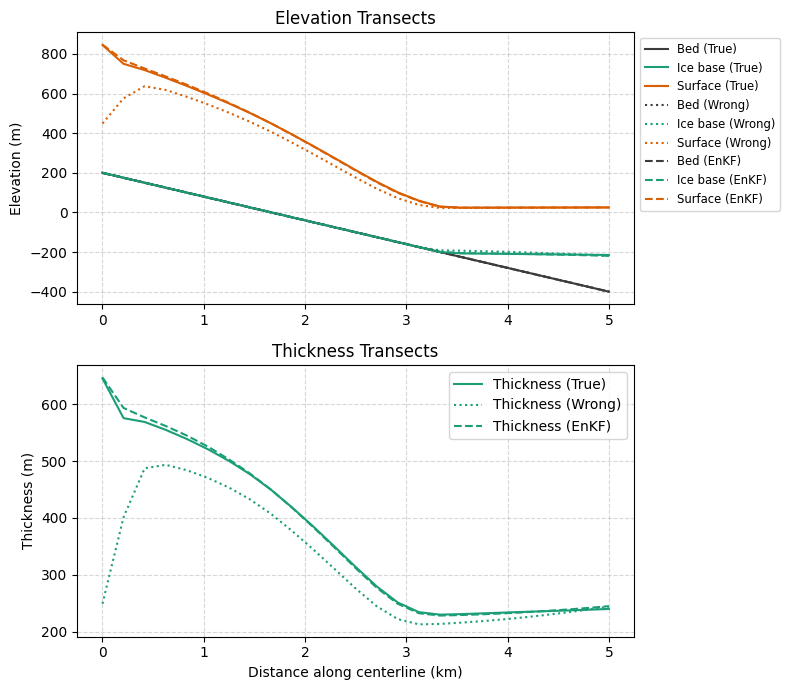

In [14]:
from firedrake import div
import copy
import icepack
import icepack.plot
import matplotlib.pyplot as plt
import numpy as np

# Define transect points
xs = np.array([(Lx * k / nx, 0) for k in range(nx + 1)])

# True simulation data
s_true = icepack.compute_surface(thickness=hhtrue, bed=b)
ss_true = np.array(s_true.at(xs, tolerance=1e-10))
bs_true = np.array(b.at(xs, tolerance=1e-10))
hs_true = np.array(hhtrue.at(xs, tolerance=1e-10))

# Wrong simulation data
s_nurge = icepack.compute_surface(thickness=hhnurge, bed=b)
ss_nurge = np.array(s_nurge.at(xs, tolerance=1e-10))
bs_nurge = np.array(b.at(xs, tolerance=1e-10))
hs_nurge = np.array(hhnurge.at(xs, tolerance=1e-10))

# EnKF simulation data
s_enkf = icepack.compute_surface(thickness=hhenkf, bed=b)
ss_enkf = np.array(s_enkf.at(xs, tolerance=1e-10))
bs_enkf = np.array(b.at(xs, tolerance=1e-10))
hs_enkf = np.array(hhenkf.at(xs, tolerance=1e-10))

# Create a 2x1 subplot layout
fig, axes = plt.subplots(2, 1, figsize=(8, 7))

# Define publication-quality colors
color_bed = '#3C3C3C'  # Dark gray for bed
color_ice_base = '#1B9E77'  # Deep teal for ice base and thickness
color_surface = '#D95F02'  # Warm red for surface

# Elevation plot (True, Wrong, and EnKF combined)
trans = 0
axes[0].plot(xs[:, trans] / 1e3, bs_true, color=color_bed, linestyle="-", label="Bed (True)")
axes[0].plot(xs[:, trans] / 1e3, ss_true - hs_true, color=color_ice_base, linestyle="-", label="Ice base (True)")
axes[0].plot(xs[:, trans] / 1e3, ss_true, color=color_surface, linestyle="-", label="Surface (True)")
axes[0].plot(xs[:, trans] / 1e3, bs_nurge, color=color_bed, linestyle=":", label="Bed (Wrong)")
axes[0].plot(xs[:, trans] / 1e3, ss_nurge - hs_nurge, color=color_ice_base, linestyle=":", label="Ice base (Wrong)")
axes[0].plot(xs[:, trans] / 1e3, ss_nurge, color=color_surface, linestyle=":", label="Surface (Wrong)")
axes[0].plot(xs[:, trans] / 1e3, bs_enkf, color=color_bed, linestyle="--", label="Bed (EnKF)")
axes[0].plot(xs[:, trans] / 1e3, ss_enkf - hs_enkf, color=color_ice_base, linestyle="--", label="Ice base (EnKF)")
axes[0].plot(xs[:, trans] / 1e3, ss_enkf, color=color_surface, linestyle="--", label="Surface (EnKF)")
axes[0].set_ylabel("Elevation (m)")
axes[0].set_title("Elevation Transects")
# axes[0].legend()
# Put legend outside the plot
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize='small')
axes[0].grid(True, linestyle='--', alpha=0.5)  # Add grid

# Thickness plot (True, Wrong, and EnKF combined)
axes[1].plot(xs[:, trans] / 1e3, hs_true, color=color_ice_base, linestyle="-", label="Thickness (True)")
axes[1].plot(xs[:, trans] / 1e3, hs_nurge, color=color_ice_base, linestyle=":", label="Thickness (Wrong)")
axes[1].plot(xs[:, trans] / 1e3, hs_enkf, color=color_ice_base, linestyle="--", label="Thickness (EnKF)")
axes[1].set_xlabel("Distance along centerline (km)")
axes[1].set_ylabel("Thickness (m)")
axes[1].set_title("Thickness Transects")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)  # Add grid

plt.tight_layout()

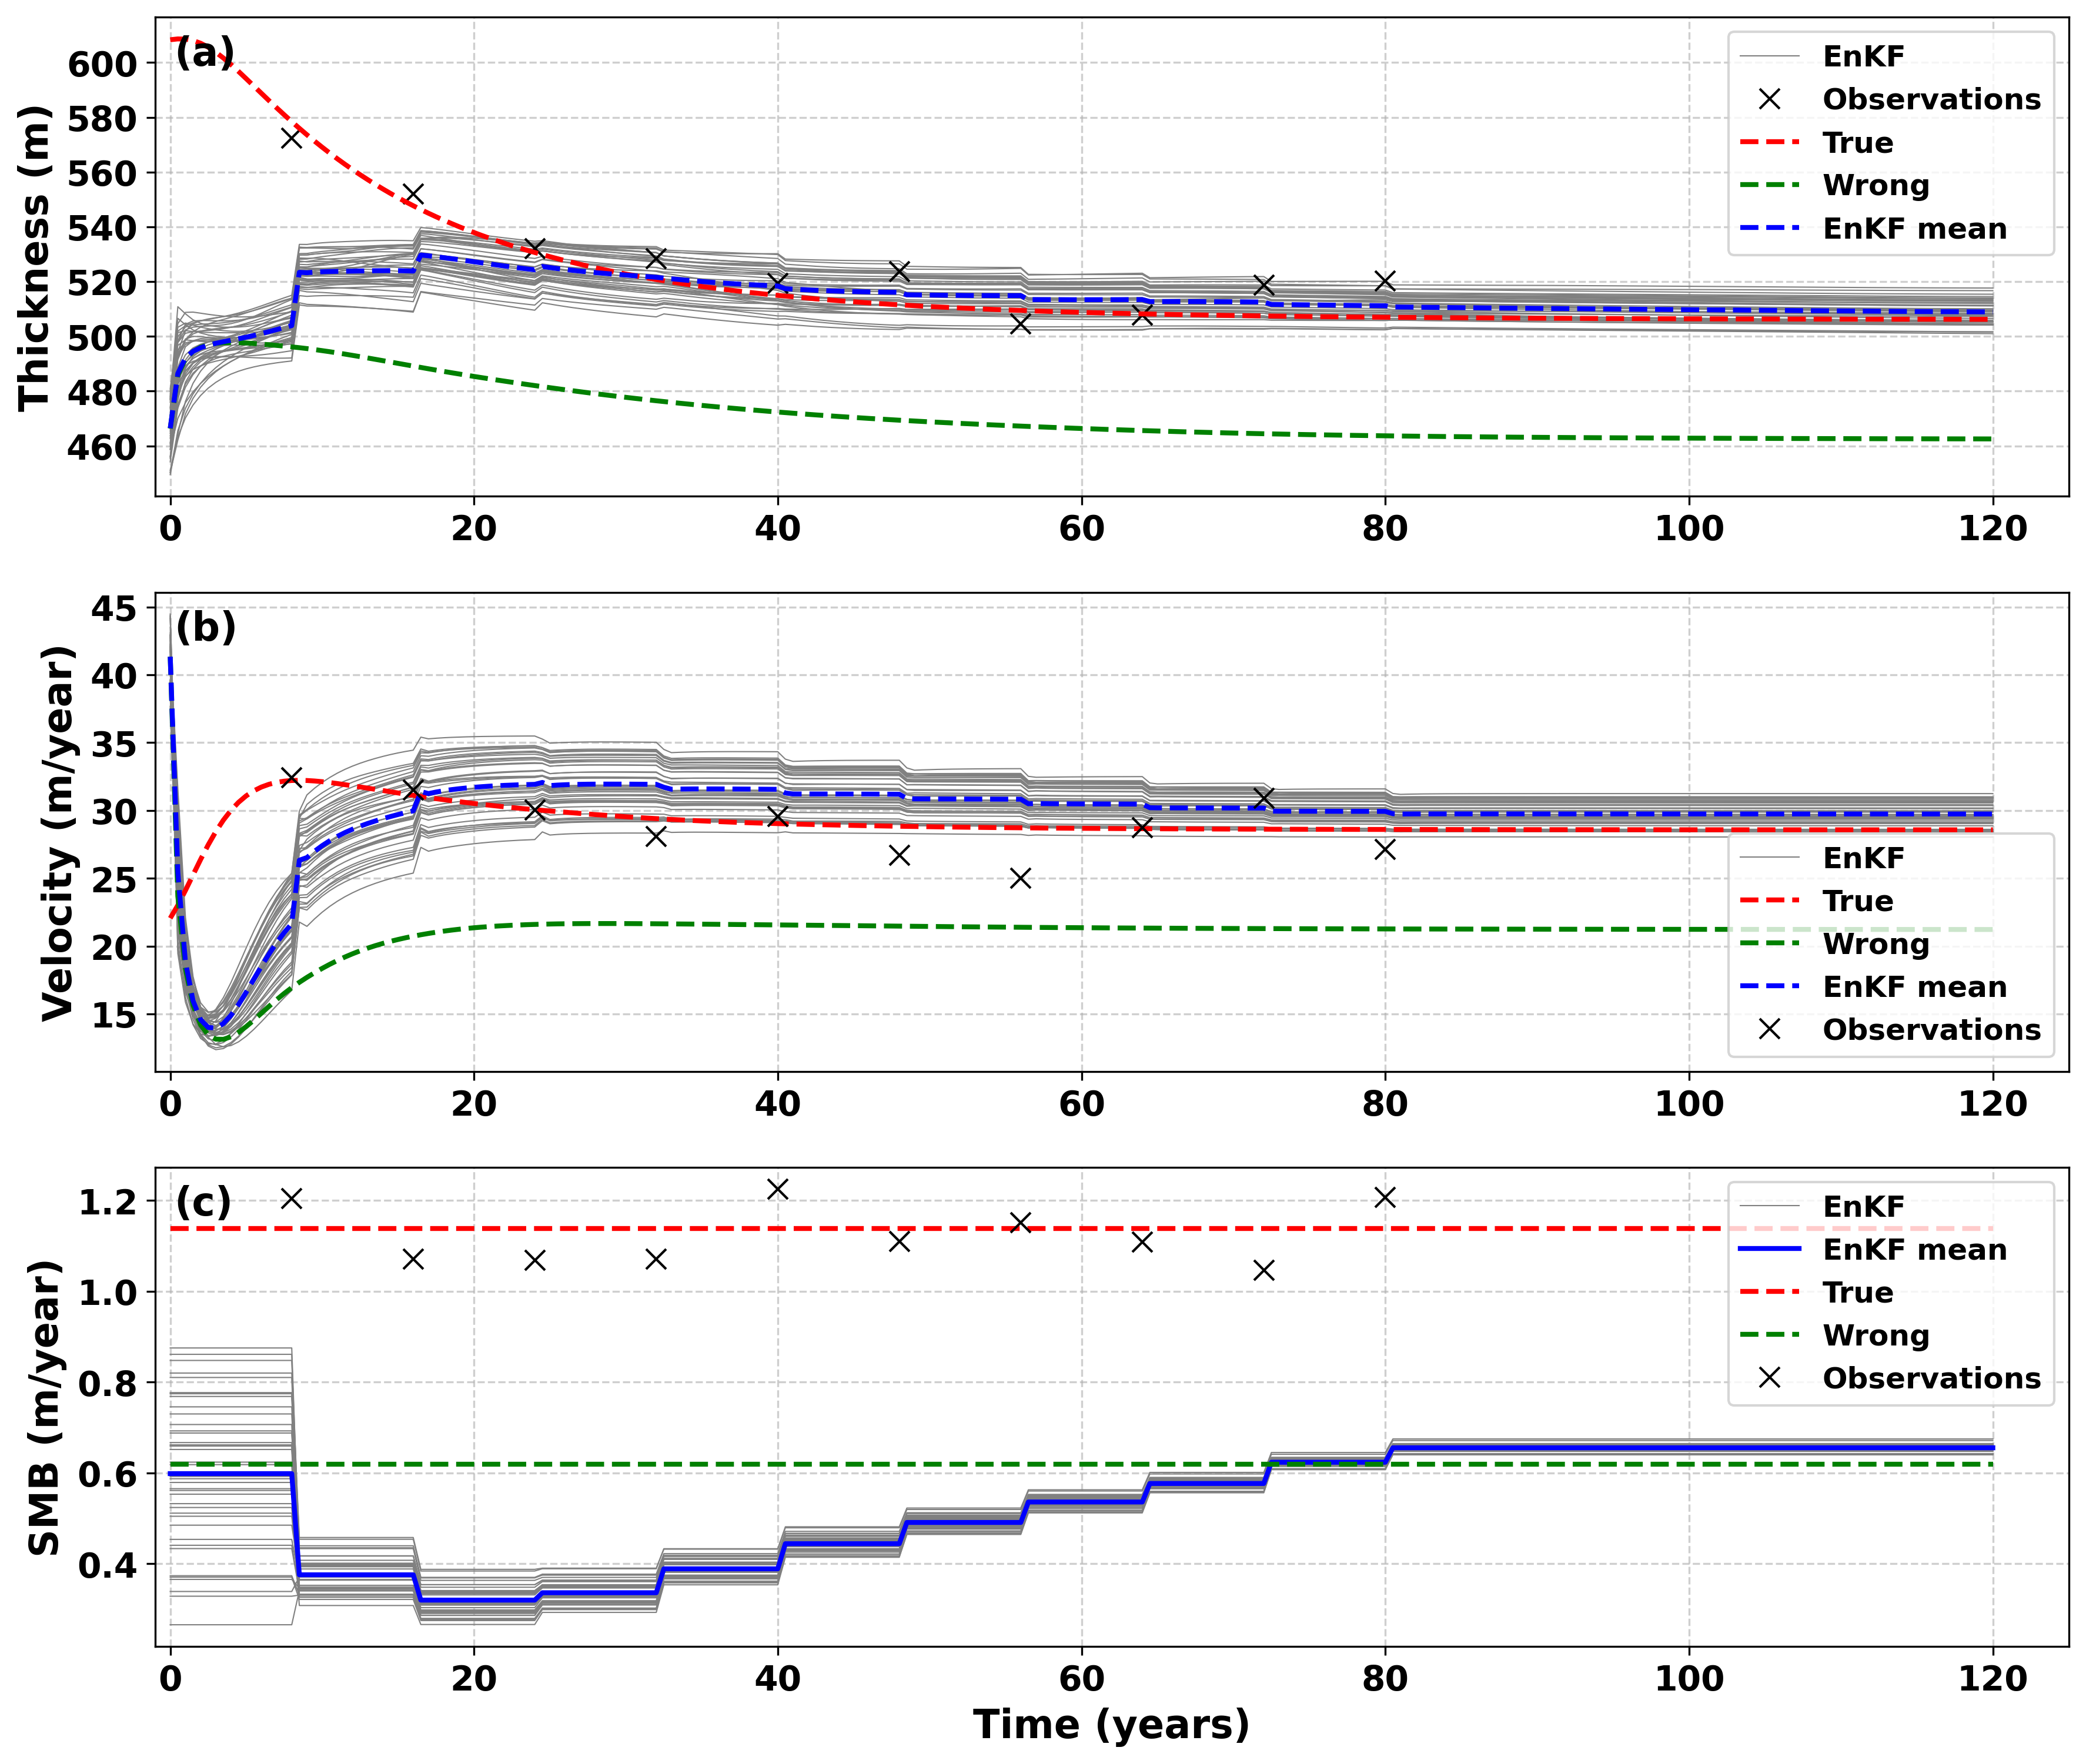

In [15]:
fig, ax = plt.subplots(3,1, figsize=(14,12), dpi=300)

# h_obs = utils_funs.Obs_fun(hu_obs[:hdim,:])
h_indx = 242 #230 # 89
obs_h = w[h_indx,:]

# _t=t[:-1]
_t = t

# plot the h middle profile
# h_indx = hens.shape[1]//2
hens = ensemble_vec_mean[:hdim,:]
h_true = htrue[h_indx,:]
h_nurged = hnurge[h_indx,:]
h_ens_mean = hens[h_indx,:]
h_ens_mem  = ensemble_vec_full[h_indx,:,:].T
# h_ob = h_ob[-1,:]
Nens = ensemble_vec_full.shape[1]
for ens in range(Nens):
    ax[0].plot(_t,h_ens_mem[:,ens], lw=0.5, color='gray',label=f"{filter_type}" if ens == 0 else "")

# ax[0].plot(ts,h_ens_mem[:,:], lw=0.5, color='k',label="DEnKF ens")
ax[0].plot(t[ind_m],obs_h,'kx',label="Observations", markersize=8)

ax[0].plot(t,h_true,'--r',label='True',linewidth=2)
ax[0].plot(t,h_nurged,'--g',label='Wrong',linewidth=2)
ax[0].plot(_t,h_ens_mean,'--b',label=f"{filter_type} mean",linewidth=2)
# ax[0].plot(t[ind_m],hu_ob[1,:],'kx',label='Observations')
ax[0].legend(prop={"size": 12, "weight": "bold"})
# ax[0].set_ylim([480, 650])
# ax[0].set_ylim([4, 650])
ax[0].set_xlim([-1,125])
# ax[0].set_xlabel('Time')
ax[0].grid(True, linestyle="--", alpha=0.6)
ax[0].set_ylabel('Thickness (m)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[0].set_xticklabels(ax[0].get_xticks(), fontweight='bold',fontsize=14)
# ax[0].set_yticklabels(ax[0].get_yticks(), fontweight='bold',fontsize=14)
# remove decinal points from x and y ticks
ax[0].set_xticklabels([int(tick) for tick in ax[0].get_xticks()], fontweight='bold',fontsize=14)
# ax[0].set_xticklabels([])
ax[0].set_yticklabels([int(tick) for tick in ax[0].get_yticks()], fontweight='bold',fontsize=14)
# ax[0].set_title(f"Ice thickness", fontdict={'fontsize': 16, 'fontweight': 'bold'})

# plot the u middle profile
# u_ob = utils_funs.Obs_fun(hu_obs[hdim:2*hdim,:])
# v_ob = utils_funs.Obs_fun(hu_obs[2*hdim:,:])
# uobs = np.sqrt(u_ob**2 + v_ob**2)
u_indx = hdim + h_indx
v_indx = 2*hdim + h_indx
obs_u = w[u_indx,:]
obs_v = w[v_indx,:]
uobs = np.sqrt(obs_u**2 + obs_v**2)
u_true = ensemble_true_state[u_indx,:]
v_true = ensemble_true_state[v_indx,:]
utrue = np.sqrt(u_true**2 + v_true**2)
u_nurge = ensemble_nurged_state[u_indx,:]
v_nurge = ensemble_nurged_state[v_indx,:]
unurge = np.sqrt(u_nurge**2 + v_nurge**2)
u_ens_mean = ensemble_vec_mean[u_indx,:]
v_ens_mean = ensemble_vec_mean[v_indx,:]
uens_mean = np.sqrt(u_ens_mean**2 + v_ens_mean**2)
u_ens_mem  = ensemble_vec_full[u_indx,:,:].T
v_ens_mem  = ensemble_vec_full[v_indx,:,:].T
uens_mem = np.sqrt(u_ens_mem**2 + v_ens_mem**2)
for ens in range(Nens):
    ax[1].plot(_t,uens_mem[:,ens], lw=0.5, color='gray',label=f"{filter_type}" if ens == 0 else "")

ax[1].plot(t,utrue,'--r',label='True',linewidth=2)
ax[1].plot(t,unurge,'--g',label='Wrong',linewidth=2)
ax[1].plot(_t,uens_mean,'--b',label=f"{filter_type} mean",linewidth=2)
ax[1].plot(t[ind_m],uobs,'kx',label='Observations', markersize=8)
ax[1].legend(prop={"size": 12, "weight": "bold"})
# ax[1].set_xlabel('Time (years)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[1].set_ylabel('Velocity (m/year)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[1].grid(True, linestyle="--", alpha=0.6)
# plt.xticks(fontweight='bold', fontsize=14)
# ax[1].set_xticklabels([])
ax[1].set_xticklabels([int(tick) for tick in ax[0].get_xticks()], fontweight='bold',fontsize=14)
ax[1].set_yticklabels([int(tick) for tick in ax[1].get_yticks()], fontweight='bold',fontsize=14)
ax[1].set_xlim([-1,125])
# ax[1].set_title(f"Ice velocity profile", fontdict={'fontsize': 16, 'fontweight': 'bold'})

# plot the smb middle profile
smb_idx = 3*hdim + h_indx
smbtrue = ensemble_true_state[smb_idx,:]
smb_nurged = ensemble_nurged_state[smb_idx,:]
smbs_ens_mean = ensemble_vec_mean[smb_idx,:]
smb_ens = ensemble_vec_full[smb_idx,:,:].T
smb_obs = w[smb_idx,:]
for ens in range(Nens):
    ax[2].plot(_t,smb_ens[:,ens], lw=0.5, color='gray',label=f"{filter_type}" if ens == 0 else "")
ax[2].plot(_t,smbs_ens_mean,'-b',label=f"{filter_type} mean",linewidth=2)
ax[2].plot(t,smbtrue,'--r',label='True',linewidth=2)
ax[2].plot(t,smb_nurged,'--g',label='Wrong',linewidth=2)
ax[2].plot(t[ind_m],smb_obs,'kx',label='Observations', markersize=8)
ax[2].set_xlabel('Time (years)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
ax[2].set_ylabel('SMB (m/year)', fontdict={'fontsize': 16, 'fontweight': 'bold'})
# plt.title(f"Surface mass balance profile", fontdict={'fontsize': 16, 'fontweight': 'bold'})
plt.xticks(fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold', fontsize=14)
ax[2].grid(True, linestyle="--", alpha=0.6)
# plt.grid()
ax[2].set_xlim([-1,125])
ax[2].legend(prop={"size": 12, "weight": "bold"})

# lets anonate each plot with (a), (b), (c)
ax[0].text(0.01, 0.9, '(a)', transform=ax[0].transAxes, fontsize=16, fontweight='bold')
ax[1].text(0.01, 0.9, '(b)', transform=ax[1].transAxes, fontsize=16, fontweight='bold')
ax[2].text(0.01, 0.9, '(c)', transform=ax[2].transAxes, fontsize=16, fontweight='bold')

# save the figure
plt.savefig(os.path.join(figure_dir, f"husmb_profile_{profile_flag}_s.png"), bbox_inches='tight', dpi=300)


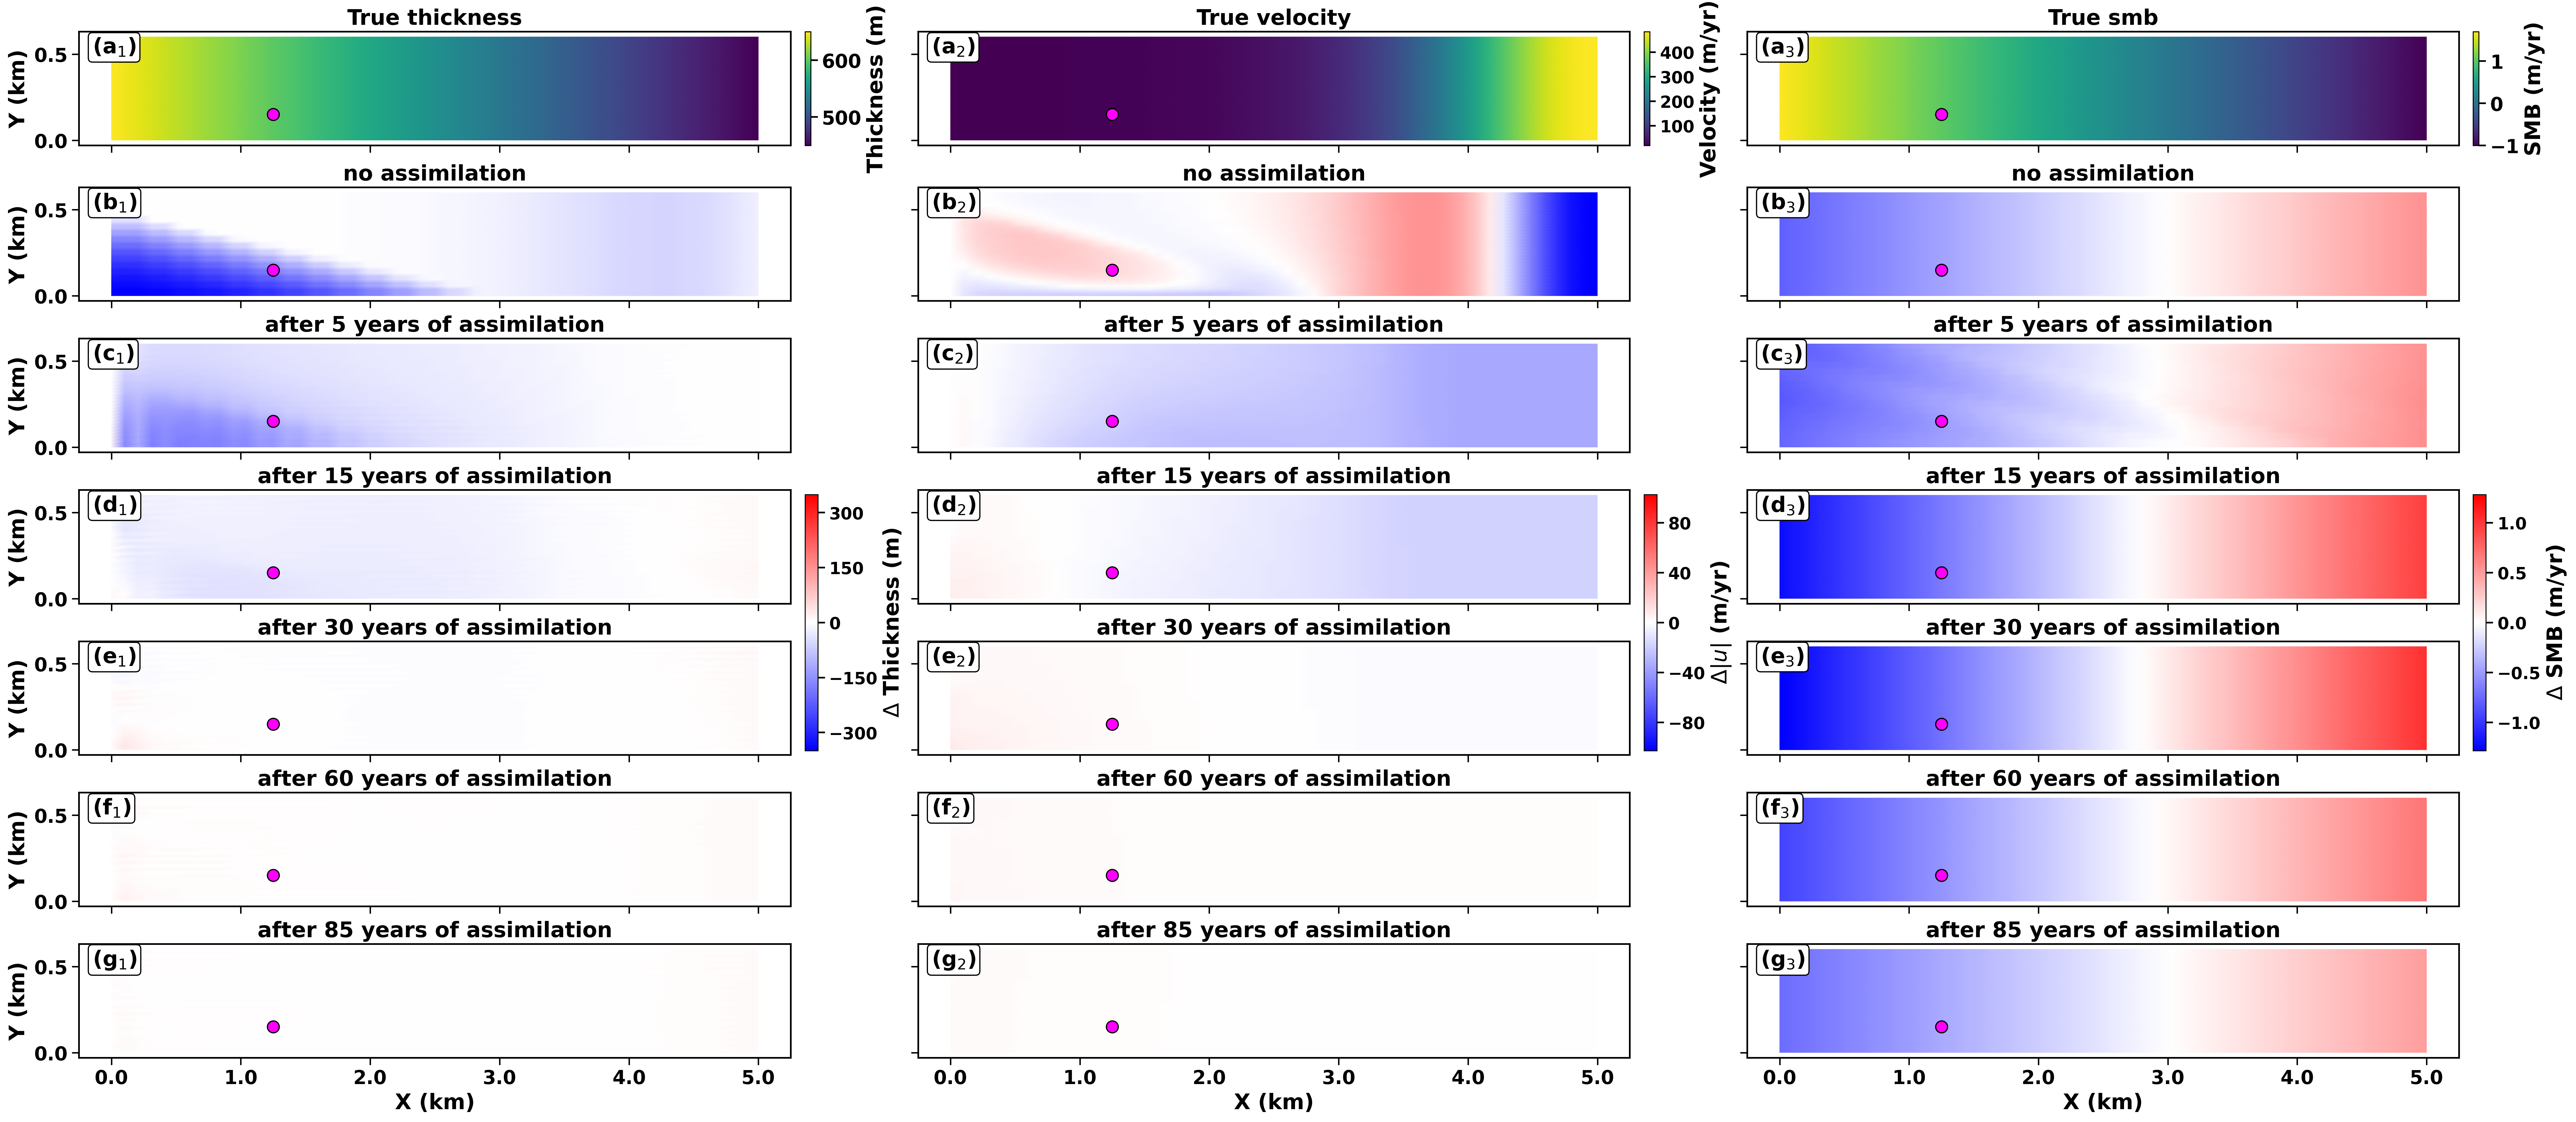

In [16]:
# ===============================================
# Firedrake functions (True / Wrong / Assimilated)
# ===============================================
def get_firedrake_functions(ensemble_true_state, ensemble_nurged_state, ensemble_vec_mean, hdim, step):
    hhtrue, hhnurge, hhenkf = firedrake.Function(Q), firedrake.Function(Q), firedrake.Function(Q)
    hhtrue.dat.data[:]  = ensemble_true_state[:hdim, step]
    hhnurge.dat.data[:] = ensemble_nurged_state[:hdim, step]     # "wrong" / no-assim
    hhenkf.dat.data[:]  = ensemble_vec_mean[:hdim, step]         # assimilated

    uutrue, uunurge, uuenkf = firedrake.Function(V), firedrake.Function(V), firedrake.Function(V)
    uutrue.dat.data[:, 0]  = ensemble_true_state[hdim:2*hdim, step]
    uutrue.dat.data[:, 1]  = ensemble_true_state[2*hdim:3*hdim, step]
    uunurge.dat.data[:, 0] = ensemble_nurged_state[hdim:2*hdim, step]
    uunurge.dat.data[:, 1] = ensemble_nurged_state[2*hdim:3*hdim, step]
    uuenkf.dat.data[:, 0]  = ensemble_vec_mean[hdim:2*hdim, step]
    uuenkf.dat.data[:, 1]  = ensemble_vec_mean[2*hdim:3*hdim, step]

    u_true_mag  = np.sqrt(uutrue.dat.data[:,0]**2  + uutrue.dat.data[:,1]**2)
    u_wrong_mag = np.sqrt(uunurge.dat.data[:,0]**2 + uunurge.dat.data[:,1]**2)
    u_enkf_mag  = np.sqrt(uuenkf.dat.data[:,0]**2  + uuenkf.dat.data[:,1]**2)

    # --- smb (new) ---
    smbtrue, smbnurge, smbenkf = firedrake.Function(Q), firedrake.Function(Q), firedrake.Function(Q)
    smbtrue.dat.data[:]  = ensemble_true_state[3*hdim:4*hdim, step]
    smbnurge.dat.data[:] = ensemble_nurged_state[3*hdim:4*hdim, step]
    smbenkf.dat.data[:]  = ensemble_vec_mean[3*hdim:4*hdim, step]

    # True ranges at this step
    hmin, hmax = hhtrue.dat.data.min(), hhtrue.dat.data.max()
    umin, umax = u_true_mag.min(), u_true_mag.max()
    smbmin, smbmax = smbtrue.dat.data.min(), smbtrue.dat.data.max()

    return (hhtrue, hhnurge, hhenkf, uutrue, uunurge, uuenkf,
            u_true_mag, u_wrong_mag, u_enkf_mag,
            smbtrue, smbnurge, smbenkf,
            hmin, hmax, umin, umax, smbmin, smbmax)


# ===============================================
# Choose steps and build figure
# ===============================================
# steps = [5, 35, 50, 75]
dt = t[1] - t[0] 
desired_years = [5, 15, 30, 60, 85]
steps = [int(np.argmin(np.abs(t - year))) for year in desired_years]
no_of_rows = len(steps) + 2

fig = plt.figure(figsize=(30, 13), dpi=300, constrained_layout=True)
gs = gridspec.GridSpec(no_of_rows, 3, figure=fig,
                       height_ratios=[1]*no_of_rows,
                       hspace=0.001, wspace=0.001)
ax = np.array([[fig.add_subplot(gs[i, j]) for j in range(3)] for i in range(no_of_rows)])


# ===============================================
# Precompute GLOBAL diff limits so all diff plots share ONE scale
# ===============================================
(hhtrue_0, hhnurge_0, hhenkf_0, uutrue_0, uunurge_0, uuenkf_0,
 u_true_mag_0, u_wrong_mag_0, u_enkf_mag_0,
 smbtrue_0, smbnurge_0, smbenkf_0,
 hmin_0, hmax_0, umin_0, umax_0, smbmin_0, smbmax_0) = \
    get_firedrake_functions(ensemble_true_state, ensemble_nurged_state, ensemble_vec_mean, hdim, 0)

# Signed diffs (IMPORTANT)
hdiff_wrong_0   = hhnurge_0.dat.data[:] - hhtrue_0.dat.data[:]
vdiff_wrong_0   = (u_wrong_mag_0 - u_true_mag_0)
smbdiff_wrong_0 = smbnurge_0.dat.data[:] - smbtrue_0.dat.data[:]
# smbdiff_wrong_0 = (smbnurge_0.dat.data[:] - 0.5*smbenkf_0.dat.data[:]) - smbtrue_0.dat.data[:]

all_hdiff   = [hdiff_wrong_0]
all_vdiff   = [vdiff_wrong_0]
all_smbdiff = [smbdiff_wrong_0]

for ii, (step, year) in enumerate(zip(steps, desired_years)):
    (hhtrue, hhnurge, hhenkf, uutrue, uunurge, uuenkf,
     u_true_mag, u_wrong_mag, u_enkf_mag,
     smbtrue, smbnurge, smbenkf,
     hmin, hmax, umin, umax, smbmin, smbmax) = \
        get_firedrake_functions(ensemble_true_state, ensemble_nurged_state, ensemble_vec_mean, hdim, step)

    all_hdiff.append(hhenkf.dat.data[:] - hhtrue.dat.data[:])
    all_vdiff.append(u_enkf_mag - u_true_mag)
    all_smbdiff.append(smbenkf.dat.data[:] - smbtrue.dat.data[:])
    # all_smbdiff.append((smbenkf_0.dat.data[:] + (ii)*0.1*smbenkf.dat.data[:]) - smbtrue.dat.data[:])

# Global symmetric limits
h_abs_global   = max(np.max(np.abs(d)) for d in all_hdiff)
u_abs_global   = max(np.max(np.abs(d)) for d in all_vdiff)
smb_abs_global = max(np.max(np.abs(d)) for d in all_smbdiff)


# ===============================================
# Row 0: True fields (each gets its own colorbar)
# ===============================================
ax[0,0].set_title("True thickness", fontsize=18, fontweight="bold", loc="center")
imt = firedrake.tripcolor(hhtrue_0, axes=ax[0,0], cmap="viridis", vmin=hmin_0, vmax=hmax_0)
ax[0,0].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)

cbt = fig.colorbar(imt, ax=ax[0,0], fraction=0.025, pad=0.02)
cbt.set_label("Thickness (m)", fontsize=18, fontweight="bold")
cbt.ax.tick_params(labelsize=16, width=1.4, direction="out", length=6)
for lab in cbt.ax.get_yticklabels():
    lab.set_fontweight("bold")

ax[0,1].set_title("True velocity", fontsize=18, fontweight="bold", loc="center")
func_true_speed = firedrake.Function(Q)
func_true_speed.dat.data[:] = u_true_mag_0
imu = firedrake.tripcolor(func_true_speed, axes=ax[0,1], cmap="viridis", vmin=umin_0, vmax=umax_0)
ax[0,1].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)

cbu = fig.colorbar(imu, ax=ax[0,1], fraction=0.025, pad=0.02)
cbu.set_label("Velocity (m/yr)", fontsize=18, fontweight="bold")
cbu.ax.tick_params(labelsize=16, width=1.4, direction="out", length=6)
for lab in cbu.ax.get_yticklabels():
    lab.set_fontweight("bold")
cbu.locator = MaxNLocator(nbins=5)
cbu.update_ticks()
cbu.ax.tick_params(labelsize=14, width=1.4, length=5)

# --- new: True smb ---
ax[0,2].set_title("True smb", fontsize=18, fontweight="bold", loc="center")
imsmb = firedrake.tripcolor(smbtrue_0, axes=ax[0,2], cmap="viridis", vmin=smbmin_0, vmax=smbmax_0)
ax[0,2].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)

cbsmb = fig.colorbar(imsmb, ax=ax[0,2], fraction=0.025, pad=0.02)
cbsmb.set_label("SMB (m/yr)", fontsize=18, fontweight="bold")
cbsmb.ax.tick_params(labelsize=16, width=1.4, direction="out", length=6)
for lab in cbsmb.ax.get_yticklabels():
    lab.set_fontweight("bold")

style_axes(ax)

# ===============================================
# Row 1: Wrong - True (NO colorbar here)
# ===============================================
h_diff   = firedrake.Function(Q)
u_diff   = firedrake.Function(Q)
smb_diff = firedrake.Function(Q)

h_diff.dat.data[:]   = hdiff_wrong_0
u_diff.dat.data[:]   = vdiff_wrong_0
smb_diff.dat.data[:] = smbdiff_wrong_0

ax[1,0].set_title("no assimilation", fontsize=18, fontweight="bold", loc="center")
im_hdiff0 = firedrake.tripcolor(h_diff, axes=ax[1,0], cmap="bwr",
                               vmin=-h_abs_global, vmax=h_abs_global)
ax[1,0].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)

ax[1,1].set_title("no assimilation", fontsize=18, fontweight="bold", loc="center")
im_udiff0 = firedrake.tripcolor(u_diff, axes=ax[1,1], cmap="bwr",
                               vmin=-u_abs_global, vmax=u_abs_global)
ax[1,1].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)

ax[1,2].set_title("no assimilation", fontsize=18, fontweight="bold", loc="center")
im_smbdiff0 = firedrake.tripcolor(smb_diff, axes=ax[1,2], cmap="bwr",
                                 vmin=-smb_abs_global, vmax=smb_abs_global)
ax[1,2].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)

style_axes(ax)

# ===============================================
# Rows 2..: EnKF - True (NO per-row colorbars)
# ===============================================
im_h_last, im_u_last, im_smb_last = im_hdiff0, im_udiff0, im_smbdiff0

for ii, (step, year) in enumerate(zip(steps, desired_years)):
    (hhtrue, hhnurge, hhenkf, uutrue, uunurge, uuenkf,
     u_true_mag, u_wrong_mag, u_enkf_mag,
     smbtrue, smbnurge, smbenkf,
     hmin, hmax, umin, umax, smbmin, smbmax) = \
        get_firedrake_functions(ensemble_true_state, ensemble_nurged_state, ensemble_vec_mean, hdim, step)

    h_diff.dat.data[:]   = (hhenkf.dat.data[:] - hhtrue.dat.data[:])
    u_diff.dat.data[:]   = (u_enkf_mag - u_true_mag)
    smb_diff.dat.data[:] = smbenkf.dat.data[:] - smbtrue.dat.data[:]
    # smb_diff.dat.data[:] = (smbenkf_0.dat.data[:] + (ii)*0.1*smbenkf.dat.data[:]) - smbtrue.dat.data[:]

    ax[ii+2, 0].set_title(f"after {year} years of assimilation", fontsize=18, fontweight="bold", loc="center")
    im_h_last = firedrake.tripcolor(h_diff, axes=ax[ii+2,0], cmap="bwr",
                                   vmin=-h_abs_global, vmax=h_abs_global)
    ax[ii+2, 1].set_title(f"after {year} years of assimilation", fontsize=18, fontweight="bold", loc="center")
    im_u_last = firedrake.tripcolor(u_diff, axes=ax[ii+2,1], cmap="bwr",
                                   vmin=-u_abs_global, vmax=u_abs_global)
    ax[ii+2, 2].set_title(f"after {year} years of assimilation", fontsize=18, fontweight="bold", loc="center")
    im_smb_last = firedrake.tripcolor(smb_diff, axes=ax[ii+2,2], cmap="bwr",
                                     vmin=-smb_abs_global, vmax=smb_abs_global)

    style_axes(ax)
    ax[ii+2,0].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)
    ax[ii+2,1].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)
    ax[ii+2,2].plot(x_h, y_h, 'o', color='magenta', markeredgecolor='black', markersize=10)


# ===============================================
# Shared colorbars for all DIFF rows (three columns)
# ===============================================
diff_axes_left   = ax[1:, 0].ravel().tolist()
diff_axes_mid    = ax[1:, 1].ravel().tolist()
diff_axes_right  = ax[1:, 2].ravel().tolist()

cb_hd = fig.colorbar(im_h_last, ax=diff_axes_left, fraction=0.018, pad=0.02)
cb_hd.set_label(r"$\Delta$ Thickness (m)", fontsize=18, fontweight="bold")
cb_hd.ax.tick_params(labelsize=16, width=1.4, direction="out", length=6)
for lab in cb_hd.ax.get_yticklabels():
    lab.set_fontweight("bold")
cb_hd.locator = MaxNLocator(nbins=6, symmetric=True)
cb_hd.update_ticks()
cb_hd.ax.tick_params(labelsize=14, width=1.4, length=6)

cb_ud = fig.colorbar(im_u_last, ax=diff_axes_mid, fraction=0.018, pad=0.02)
cb_ud.set_label(r"$\Delta |u|$ (m/yr)", fontsize=18, fontweight="bold")
cb_ud.ax.tick_params(labelsize=16, width=1.4, direction="out", length=6)
for lab in cb_ud.ax.get_yticklabels():
    lab.set_fontweight("bold")
cb_ud.locator = MaxNLocator(nbins=6, symmetric=True)
cb_ud.update_ticks()
cb_ud.ax.tick_params(labelsize=14, width=1.4, length=6)

cb_smbd = fig.colorbar(im_smb_last, ax=diff_axes_right, fraction=0.018, pad=0.02)
cb_smbd.set_label(r"$\Delta$ SMB (m/yr)", fontsize=18, fontweight="bold")
cb_smbd.ax.tick_params(labelsize=16, width=1.4, direction="out", length=6)
for lab in cb_smbd.ax.get_yticklabels():
    lab.set_fontweight("bold")
cb_smbd.locator = MaxNLocator(nbins=6, symmetric=True)
cb_smbd.update_ticks()
cb_smbd.ax.tick_params(labelsize=14, width=1.4, length=6)

# ===============================================
# Axes formatting
# ===============================================
for i in range(no_of_rows):
    for j in range(3):
        ax[i,j].tick_params(axis='both', labelsize=17, width=1.2)
        ax[i,j].xaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
        ax[i,j].yaxis.set_major_formatter(StrMethodFormatter('{x:.0f}'))
        if i == no_of_rows-1:
            ax[i,j].set_xlabel("X (km)", fontsize=18, fontweight="bold")
            ax[i,j].set_xticklabels([float(tick/1000) for tick in ax[i,j].get_xticks()], fontweight='bold', fontsize=16)
        else:
            ax[i,j].set_xticklabels([])
        if j == 0:
            ax[i,j].set_ylabel("Y (km)", fontsize=18, fontweight="bold")
            ax[i,j].set_yticklabels([float(tick/1000) for tick in ax[i,j].get_yticks()], fontweight='bold', fontsize=16)
        else:
            ax[i,j].set_yticklabels([])
        plt.setp(ax[i,j].get_xticklabels(), fontweight='bold')
        plt.setp(ax[i,j].get_yticklabels(), fontweight='bold')

# add_panel_labels(ax, fontsize=18)
plt.subplots_adjust(left=0.04, right=0.98, top=0.97, bottom=0.05)

# ===============================================
# Panel labels: a1,a2,a3 / b1,b2,b3 / ... across all rows and 3 columns
# ===============================================
# row_letters = ['a', 'b', 'c', 'd', 'e', 'f']  # extend if no_of_rows > 6
row_letters = [chr(ord('a') + i) for i in range(no_of_rows)]  # Generate letters a, b, c, ...
for i in range(no_of_rows):
    for j in range(3):
        label = f"({row_letters[i]}$_{{{j+1}}}$)"
        ax[i, j].text(0.019, 0.81, label, transform=ax[i, j].transAxes,
                       fontsize=18, fontweight="bold",
                       bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.2'))

plt.subplots_adjust(left=0.04, right=0.98, top=0.97, bottom=0.05)


plt.savefig(os.path.join(figure_dir, "husmb_true_diff.png"), bbox_inches='tight', dpi=300)
plt.show()

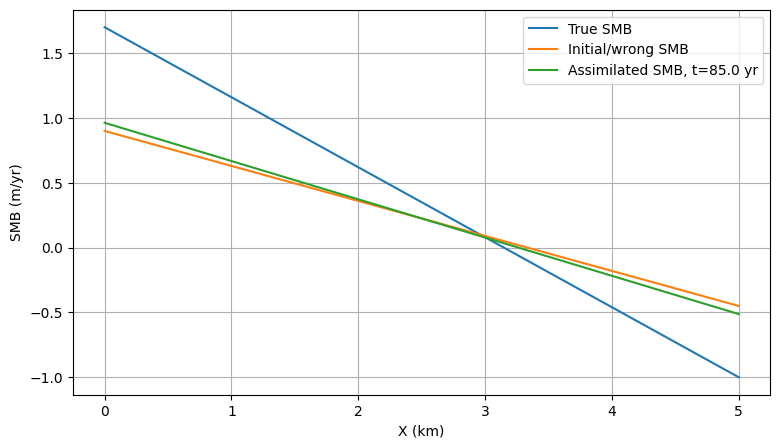

In [17]:
mesh = Q.mesh()
x_expr, y_expr = firedrake.SpatialCoordinate(mesh)

x_function = firedrake.Function(Q).interpolate(x_expr)
y_function = firedrake.Function(Q).interpolate(y_expr)

xcoord = x_function.dat.data_ro.copy()
ycoord = y_function.dat.data_ro.copy()

order = np.argsort(xcoord)

true_smb = smbtrue.dat.data_ro.copy()
wrong_smb = smbnurge.dat.data_ro.copy()
analysis_smb = smbenkf.dat.data_ro.copy()

plt.figure(figsize=(9, 5))
plt.plot(
    xcoord[order] / 1000,
    true_smb[order],
    label="True SMB"
)
plt.plot(
    xcoord[order] / 1000,
    wrong_smb[order],
    label="Initial/wrong SMB"
)
plt.plot(
    xcoord[order] / 1000,
    analysis_smb[order],
    label=f"Assimilated SMB, t={t[step]:.1f} yr"
)

plt.xlabel("X (km)")
plt.ylabel("SMB (m/yr)")
plt.legend()
plt.grid(True)
plt.show()

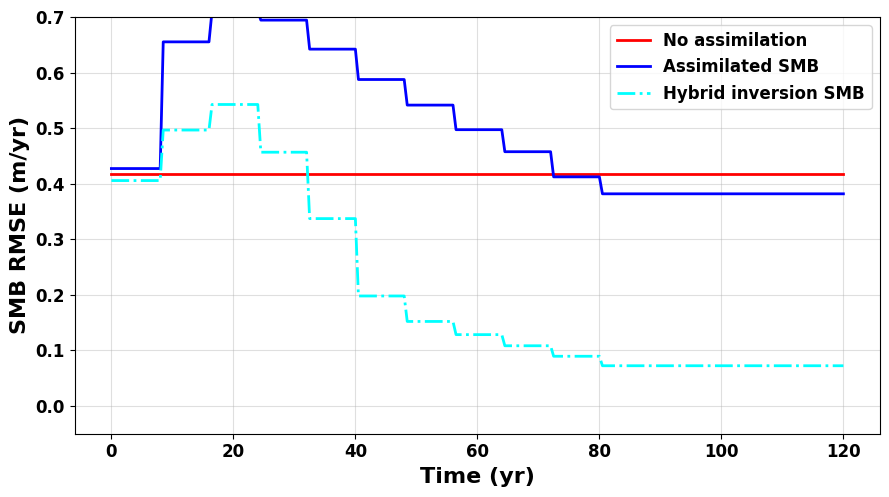

In [18]:
# ===============================================
# Load additional SMB-inversion datasets
# ===============================================
def load_ensemble_mean(dir_path, filename='icesee_ensemble_data.h5'):
    import h5py
    file_path = f"{dir_path}/{filename}"
    with h5py.File(file_path, 'r') as f:
        ensemble_mean = f['ensemble_mean'][:]
    return ensemble_mean

# EnKF-based SMB retrieval (continuity-equation inversion)
ensemble_mean_esmb = load_ensemble_mean('_modelrun_datasets')

# Hybrid method SMB retrieval
ensemble_mean_ismb = load_ensemble_mean('_modelrun_datasets_ismb')

# ===============================================
# Timeseries RMSE of SMB (entire domain) vs time
# ===============================================
smb_true_all  = ensemble_true_state[3*hdim:4*hdim, :]
smb_wrong_all = ensemble_nurged_state[3*hdim:4*hdim, :]
# smb_enkf_all  = ensemble_vec_mean[3*hdim:4*hdim, :]
smb_esmb_all  = ensemble_mean_esmb[3*hdim:4*hdim, :]
smb_ismb_all  = ensemble_mean_ismb[3*hdim:4*hdim, :]

rmse_wrong = np.sqrt(np.mean((smb_wrong_all - smb_true_all)**2, axis=0))
# rmse_enkf  = np.sqrt(np.mean((smb_enkf_all  - smb_true_all)**2, axis=0))
rmse_esmb  = np.sqrt(np.mean((smb_esmb_all  - smb_true_all)**2, axis=0))
rmse_ismb  = np.sqrt(np.mean((smb_ismb_all  - smb_true_all)**2, axis=0))

plt.figure(figsize=(9, 5))
plt.plot(t, rmse_wrong, label="No assimilation",              color="r",    lw=2)
plt.plot(t, rmse_esmb,  label="Assimilated SMB",            color="b",   lw=2)
# plt.plot(t, rmse_enkf,  label="EnKF inversion (continuity eq.)", color="tab:green",  lw=2, linestyle="--")
plt.plot(t, rmse_ismb,  label="Hybrid inversion SMB",              color="cyan", lw=2, linestyle="-.")
plt.xlabel("Time (yr)", fontsize=16, fontweight="bold")
plt.ylabel("SMB RMSE (m/yr)", fontsize=16, fontweight="bold")
# plt.title("Domain-wide SMB RMSE over time", fontsize=15, fontweight="bold")
plt.legend(prop={"size": 12, "weight": "bold"})
plt.xticks(fontweight='bold', fontsize=14)
plt.yticks(fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.4)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.ylim([-0.05,0.7])
plt.savefig(os.path.join(figure_dir, "smb_rmse_timeseries_comparison.png"), dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# _, indx_map, _ = icesee_get_index(ensemble_vec_mean, **kwargs)
# smb_idx = 3*hdim:4*hdim

print(
    f"{'Requested':>10} "
    f"{'Actual':>10} "
    f"{'RMSE':>12} "
    f"{'Max error':>12} "
    f"{'Mean error':>12}"
)

for year, step in zip(desired_years, steps):
    truth = ensemble_true_state[3*hdim:4*hdim, step]
    estimate = ensemble_vec_mean[3*hdim:4*hdim, step]
    error = estimate - truth

    print(
        f"{year:10.1f} "
        f"{t[step]:10.1f} "
        f"{np.sqrt(np.mean(error**2)):12.6f} "
        f"{np.max(np.abs(error)):12.6f} "
        f"{np.mean(error):12.6f}"
    )

 Requested     Actual         RMSE    Max error   Mean error
       5.0        5.0     0.427247     0.846854    -0.125000
      15.0       15.0     0.655251     1.216576    -0.125000
      30.0       30.0     0.694388     1.284164    -0.125000
      60.0       60.0     0.497208     0.941690    -0.125000
      85.0       85.0     0.381772     0.737175    -0.125000


In [20]:
vec_inputs = ['h', 'u', 'v', 'smb']
# _, indx_map, _ = icesee_get_index(ensemble_vec_mean, **kwargs)

indx_map = {
    'h': slice(0, hdim),
    'u': slice(hdim, 2*hdim),
    'v': slice(2*hdim, 3*hdim),
    'smb': slice(3*hdim, 4*hdim)
}
for var in vec_inputs:
    idx = indx_map[var]
    print(f"\n=== {var} ===")
    print(
        f"{'Requested':>10} "
        f"{'Actual':>10} "
        f"{'RMSE':>12} "
        f"{'Max error':>12} "
        f"{'Mean error':>12}"
    )
    for year, step in zip(desired_years, steps):
        truth = ensemble_true_state[idx, step]
        estimate = ensemble_vec_mean[idx, step]
        error = estimate - truth
        print(
            f"{year:10.1f} "
            f"{t[step]:10.1f} "
            f"{np.sqrt(np.mean(error**2)):12.6f} "
            f"{np.max(np.abs(error)):12.6f} "
            f"{np.mean(error):12.6f}"
        )


=== h ===
 Requested     Actual         RMSE    Max error   Mean error
       5.0        5.0    58.411969   175.029256   -40.269609
      15.0       15.0    19.921563    42.753370   -15.290569
      30.0       30.0     4.112202    34.290976    -0.479798
      60.0       60.0     3.738734    16.537020     3.036623
      85.0       85.0     2.660578    11.543813     1.939525

=== u ===
 Requested     Actual         RMSE    Max error   Mean error
       5.0        5.0    24.648894    35.082136   -22.141429
      15.0       15.0    11.962176    17.776348    -9.173348
      30.0       30.0     2.174200     8.762691     0.185077
      60.0       60.0     1.580168     3.663663     1.497855
      85.0       85.0     0.960507     2.868862     0.852609

=== v ===
 Requested     Actual         RMSE    Max error   Mean error
       5.0        5.0     2.385118     6.422928    -1.617569
      15.0       15.0     0.472124     3.779147    -0.151282
      30.0       30.0     0.405701     3.716583     